# Catastrophe Bond Pricing Analysis

This notebook contains the full empirical analysis behind the paper *"What Drives Catastrophe Bond Spreads?"*. It takes our hand-collected, tranche-level catastrophe bond dataset and works through the whole pipeline: loading and cleaning the data, exploring it, running the four stepwise OLS regressions reported in the paper, training and tuning the machine-learning models, and finally interpreting them with SHAP.

The question we are trying to answer is to what extent four characteristics explain the **spread** a catastrophe bond pays: the **expected loss** (`expected_loss_pct`, our main explanatory variable), the **trigger mechanism**, the **peril type**, and the **issuance year**. The spread (`spread_pct`) is the dependent variable throughout. Everything below is structured to build up that answer step by step, mirroring the order of the Results section in the paper.

A quick note on interpretation: this is an observational, manually built sample, so all results should be read as associations between bond characteristics and spreads, not as causal effects.

## Import packages

Loads everything used in the notebook: pandas/numpy for data handling, matplotlib for the figures, and statsmodels for the OLS regressions. The display settings just make tables easier to read (more columns shown, three decimal places). Run this first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Load the dataset

Reads in our tranche-level dataset. This is the data we collected ourselves from the individual deal pages on the Artemis Deal Directory, extracted with the help of an LLM and then manually checked against the source pages. The `Data` sheet holds one row per bond tranche, which is our unit of observation (a single deal can contain several tranches with different spreads and expected losses, so we keep them separate rather than aggregating to the deal level).

In [2]:
# The main dataset is stored in the Data sheet.
df = pd.read_excel("artemis_cat_bond_tranche_dataset_extended.xlsx")


df.head()

,deal_name,issuer,sponsor,issue_year,issue_month,tranche_class,peril_type,trigger_type,coverage_basis,tranche_size_m,expected_loss_pct,spread_pct,spread_basis,source_url,validation_status,notes,regression_ready,spread_to_el_multiple
0,Alamo Re Ltd. (Series 2014-1),Alamo Re Ltd.,Texas Windstorm Insurance Association (TWIA),2014,Jun,Class A,Texas named storms,Indemnity,Annual aggregate,400.000,2.840,6.350,Final spread,https://www.artemis.bm/deal-directory/alamo-re...,Checked against Artemis page/text,Artemis page gives EL 2.84%; final coupon/spre...,Yes,2.236
1,Citrus Re Ltd. (Series 2014-1),Citrus Re Ltd.,Heritage Property and Casualty Insurance Co.,2014,Apr,Class A,U.S. named storms (Florida initially),Indemnity,Per-occurrence,150.000,1.280,4.250,Final spread,https://www.artemis.bm/deal-directory/citrus-r...,Checked against Artemis page/text,Artemis page gives EL 1.28%; final coupon 4.25%.,Yes,3.320
2,Tradewynd Re Ltd. (Series 2014-1),Tradewynd Re Ltd.,AIG,2014,Dec,Class 1-B,"Named storm and earthquake: U.S., Canada, Mexi...",Indemnity,Per-occurrence,100.000,2.200,6.750,Final spread,https://www.artemis.bm/deal-directory/tradewyn...,Checked against Artemis page/text,Final pricing stated by Artemis.,Yes,3.068
3,Tradewynd Re Ltd. (Series 2014-1),Tradewynd Re Ltd.,AIG,2014,Dec,Class 3-A,"Named storm and earthquake: U.S., Canada, Mexi...",Indemnity,Per-occurrence,100.000,1.140,5.000,Final spread,https://www.artemis.bm/deal-directory/tradewyn...,Checked against Artemis page/text,Final pricing stated by Artemis.,Yes,4.386
4,Tradewynd Re Ltd. (Series 2014-1),Tradewynd Re Ltd.,AIG,2014,Dec,Class 3-B,"Named storm and earthquake: U.S., Canada, Mexi...",Indemnity,Per-occurrence,300.000,2.200,7.000,Final spread,https://www.artemis.bm/deal-directory/tradewyn...,Checked against Artemis page/text,Final pricing stated by Artemis.,Yes,3.182


## Clean column names and inspect structure

A light cleanup pass. It drops any fully empty columns that Excel sometimes adds and prints the shape and column list so we can confirm the file loaded as expected before doing anything with it.

In [3]:
df = df.dropna(axis=1, how="all")

print(f"Cleaned shape: {df.shape}")
print(df.columns.tolist())
df.info()

Cleaned shape: (157, 18)
['deal_name', 'issuer', 'sponsor', 'issue_year', 'issue_month', 'tranche_class', 'peril_type', 'trigger_type', 'coverage_basis', 'tranche_size_m', 'expected_loss_pct', 'spread_pct', 'spread_basis', 'source_url', 'validation_status', 'notes', 'regression_ready', 'spread_to_el_multiple']
<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   deal_name              157 non-null    str    
 1   issuer                 157 non-null    str    
 2   sponsor                157 non-null    str    
 3   issue_year             157 non-null    int64  
 4   issue_month            156 non-null    str    
 5   tranche_class          157 non-null    str    
 6   peril_type             157 non-null    str    
 7   trigger_type           157 non-null    str    
 8   coverage_basis         157 non-null    str    
 9   tranche_size_m   

## Convert variables to the correct types

Makes sure each column has the right type before analysis. The numeric variables we actually model (spread, expected loss, issue year, tranche size) are forced to numbers, and anything that should be text (deal name, sponsor, trigger type, peril type, etc.) is stored as a clean string. We also recompute the spread-to-expected-loss multiple here ourselves rather than trusting whatever Excel formula produced it, so the value is fully reproducible from the raw inputs.

In [4]:
numeric_cols = ["issue_year", "tranche_size_m", "expected_loss_pct", "spread_pct", "spread_to_el_multiple"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

text_cols = [
    "deal_name", "issuer", "sponsor", "tranche_class", "peril_type",
    "trigger_type", "coverage_basis", "spread_basis", "validation_status",
    "regression_ready", "source_url", "notes"
]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Standardise yes/no field.
if "regression_ready" in df.columns:
    df["regression_ready"] = df["regression_ready"].str.title()

# Recalculate spread-to-expected-loss multiple to avoid relying on Excel formulas.
df["spread_to_el_multiple_calc"] = np.where(
    df["expected_loss_pct"] > 0,
    df["spread_pct"] / df["expected_loss_pct"],
    np.nan
)

df[["issue_year", "expected_loss_pct", "spread_pct", "trigger_type", "peril_type", "regression_ready"]].head()

,issue_year,expected_loss_pct,spread_pct,trigger_type,peril_type,regression_ready
0,2014,2.840,6.350,Indemnity,Texas named storms,Yes
1,2014,1.280,4.250,Indemnity,U.S. named storms (Florida initially),Yes
2,2014,2.200,6.750,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi...",Yes
3,2014,1.140,5.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi...",Yes
4,2014,2.200,7.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi...",Yes


## Basic data quality checks

A first sanity check on the dataset. It reports how many tranches we have in total, how many are flagged as regression-ready, how many have the key variables present, and the year range and number of unique deals and sponsors. This is mainly there so we can be transparent in the paper about how complete the data is and where the 153 final observations come from.

In [5]:
quality_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Regression-ready rows",
        "Rows with spread",
        "Rows with expected loss",
        "Rows with both spread and expected loss",
        "Earliest issue year",
        "Latest issue year",
        "Unique deals",
        "Unique sponsors"
    ],
    "value": [
        len(df),
        (df["regression_ready"] == "Yes").sum() if "regression_ready" in df.columns else np.nan,
        df["spread_pct"].notna().sum(),
        df["expected_loss_pct"].notna().sum(),
        df[["spread_pct", "expected_loss_pct"]].dropna().shape[0],
        int(df["issue_year"].min()),
        int(df["issue_year"].max()),
        df["deal_name"].nunique(),
        df["sponsor"].nunique() if "sponsor" in df.columns else np.nan
    ]
})

quality_summary

,metric,value
0,Total rows,157
1,Regression-ready rows,153
2,Rows with spread,157
3,Rows with expected loss,153
4,Rows with both spread and expected loss,153
5,Earliest issue year,2014
6,Latest issue year,2026
7,Unique deals,84
8,Unique sponsors,59


## Missing values table

Shows exactly which columns have missing values and how often. This backs up the data section of the paper: we keep only tranches where all the variables we need are present, and this table documents what was incomplete before that filtering happened.

In [6]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
      .sort_values("missing_pct", ascending=False)
)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct
notes,85,54.140
tranche_size_m,29,18.471
expected_loss_pct,4,2.548
spread_to_el_multiple,4,2.548
spread_to_el_multiple_calc,4,2.548
issue_month,1,0.637


## Build the regression sample

This is where the analysis sample is created. We keep only the tranches marked as regression-ready and drop any row missing one of the variables we rely on (spread, expected loss, issue year, trigger type, peril type). We also remove economically impossible rows where spread or expected loss is not positive. What comes out of this step is the 153-tranche sample used everywhere else in the paper.

In [7]:
reg = df.copy()

if "regression_ready" in reg.columns:
    reg = reg[reg["regression_ready"] == "Yes"].copy()

reg = reg.dropna(subset=["spread_pct", "expected_loss_pct", "issue_year", "trigger_type", "peril_type"]).copy()

# Keep economically valid rows.
reg = reg[(reg["spread_pct"] > 0) & (reg["expected_loss_pct"] > 0)].copy()

print(f"Regression sample size: {len(reg)}")
reg[["deal_name", "tranche_class", "issue_year", "expected_loss_pct", "spread_pct", "trigger_type", "peril_type"]].head()

Regression sample size: 153


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,trigger_type,peril_type
0,Alamo Re Ltd. (Series 2014-1),Class A,2014,2.840,6.350,Indemnity,Texas named storms
1,Citrus Re Ltd. (Series 2014-1),Class A,2014,1.280,4.250,Indemnity,U.S. named storms (Florida initially)
2,Tradewynd Re Ltd. (Series 2014-1),Class 1-B,2014,2.200,6.750,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi..."
3,Tradewynd Re Ltd. (Series 2014-1),Class 3-A,2014,1.140,5.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi..."
4,Tradewynd Re Ltd. (Series 2014-1),Class 3-B,2014,2.200,7.000,Indemnity,"Named storm and earthquake: U.S., Canada, Mexi..."


## Group perils into broader categories

The raw peril descriptions on Artemis are very granular (lots of slightly different wordings for similar risks). Splitting the regression across all of those would create many tiny dummy variables with almost no observations each, which the model can't estimate reliably. So we collapse them into a small set of broad categories (Wind/Storm, Earthquake, Multi-peril, Flood, and so on). We also store trigger type and issuance year as categorical variables here so they enter the regressions as dummies rather than as numbers.

In [8]:
def classify_peril(text):
    text = str(text).lower()
    if any(word in text for word in ["multi", "multiple", "named storm and earthquake", "storm and earthquake"]):
        return "Multi-peril"
    if any(word in text for word in ["hurricane", "named storm", "wind", "typhoon", "cyclone"]):
        return "Wind/Storm"
    if "earthquake" in text or "quake" in text:
        return "Earthquake"
    if "wildfire" in text or "fire" in text:
        return "Wildfire"
    if "flood" in text:
        return "Flood"
    if "mortality" in text or "pandemic" in text:
        return "Mortality/Pandemic"
    return "Other"

reg["broad_peril"] = reg["peril_type"].apply(classify_peril).astype("category")
reg["trigger_type"] = reg["trigger_type"].astype("category")
reg["issue_year_cat"] = reg["issue_year"].astype(int).astype("category")

reg[["peril_type", "broad_peril", "trigger_type"]].head(10)

,peril_type,broad_peril,trigger_type
0,Texas named storms,Wind/Storm,Indemnity
1,U.S. named storms (Florida initially),Wind/Storm,Indemnity
2,"Named storm and earthquake: U.S., Canada, Mexi...",Multi-peril,Indemnity
3,"Named storm and earthquake: U.S., Canada, Mexi...",Multi-peril,Indemnity
4,"Named storm and earthquake: U.S., Canada, Mexi...",Multi-peril,Indemnity
5,California earthquake,Earthquake,Indemnity
6,California earthquake,Earthquake,Indemnity
7,Turkey earthquake,Earthquake,Parametric
8,Florida named storms,Wind/Storm,Indemnity
9,Japan earthquake,Earthquake,Indemnity


# Exploratory Data Analysis

The next block of cells looks at the data descriptively, before any regression. The goal is to get an initial feel for each relationship on its own: how spread relates to expected loss, and how spreads differ across trigger types, perils, and years. These are univariate views, so they don't control for anything yet; that is exactly why we follow them with the regressions, which test whether the patterns survive once all the variables are included together.

## Descriptive statistics for the main numeric variables

Summary statistics (mean, spread, min/median/max) for the continuous variables. These are the numbers behind Table I in the paper, including the point that average spread (about 7.2%) sits well above average expected loss (about 2.8%), which is the basic evidence that investors are paid a premium on top of modelled loss.

In [9]:
main_numeric = ["spread_pct", "expected_loss_pct", "spread_to_el_multiple_calc", "tranche_size_m", "issue_year"]
reg[main_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
spread_pct,153.000,7.202,3.544,1.875,4.500,6.500,9.250,20.000
expected_loss_pct,153.000,2.840,1.998,0.115,1.290,2.200,4.030,9.720
spread_to_el_multiple_calc,153.000,3.623,4.099,1.066,1.997,2.551,3.893,42.308
tranche_size_m,125.000,152.412,110.577,25.000,75.000,125.000,200.000,500.000
issue_year,153.000,"2,021.967",4.165,"2,014.000","2,017.000","2,024.000","2,026.000","2,026.000"


## Sample composition by issuance year

This plot shows the number of tranches issued in each year. The distribution is clearly uneven over time, with fewer observations in the earlier years and a larger number of observations in the more recent period. This is relevant because it supports the use of issuance-year controls in the later analysis. At the same time, it should be interpreted as a limitation, since the fixed effects for years with only a small number of tranches are based on limited observations and should therefore be read with caution.

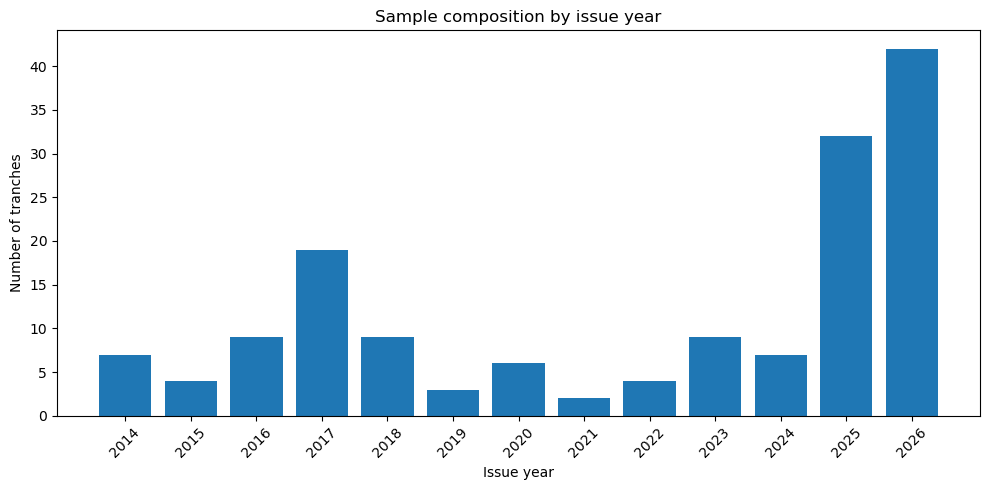

,n_tranches
issue_year,
2014,7
2015,4
2016,9
2017,19
2018,9
2019,3
2020,6
2021,2
2022,4


In [10]:
year_counts = reg["issue_year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.xlabel("Issue year")
plt.ylabel("Number of tranches")
plt.title("Sample composition by issue year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

year_counts.to_frame("n_tranches")

## Sample composition by trigger type

Counts of tranches per trigger mechanism. It makes clear that the sample is dominated by indemnity triggers, with industry-loss index next and only a handful of parametric tranches. That imbalance is the reason the parametric estimates later are imprecise, so this chart is useful context for the trigger results.

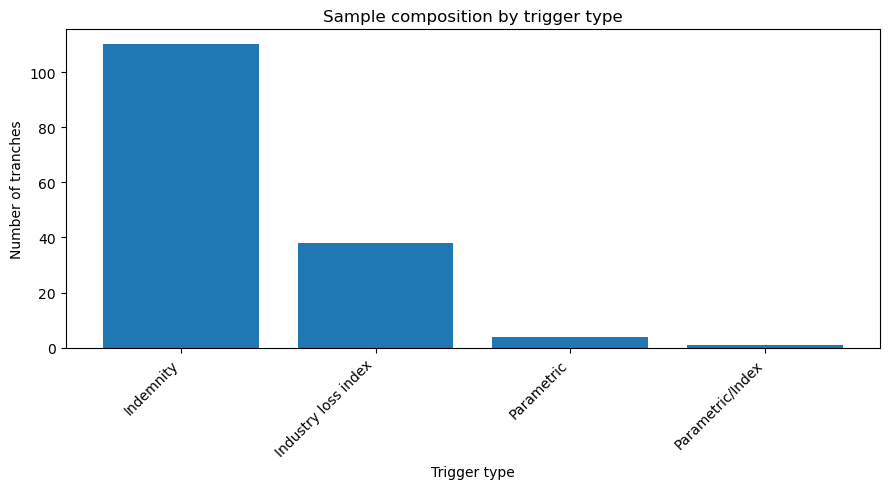

,n_tranches
trigger_type,
Indemnity,110
Industry loss index,38
Parametric,4
Parametric/Index,1


In [11]:
trigger_counts = reg["trigger_type"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(trigger_counts.index.astype(str), trigger_counts.values)
plt.xlabel("Trigger type")
plt.ylabel("Number of tranches")
plt.title("Sample composition by trigger type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

trigger_counts.to_frame("n_tranches")

## Sample composition by broad peril category

Counts of tranches per broad peril category. Wind/Storm is by far the most common, with Earthquake and Multi-peril also reasonably represented and Flood and Other quite rare. As with triggers, this tells us which peril estimates are well supported by data and which rest on only a few observations.

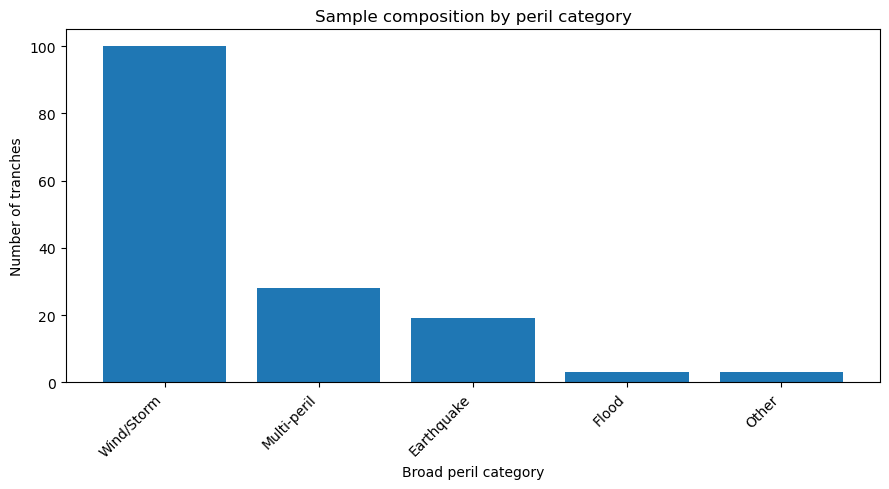

,n_tranches
broad_peril,
Wind/Storm,100
Multi-peril,28
Earthquake,19
Flood,3
Other,3


In [12]:
peril_counts = reg["broad_peril"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(peril_counts.index.astype(str), peril_counts.values)
plt.xlabel("Broad peril category")
plt.ylabel("Number of tranches")
plt.title("Sample composition by peril category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

peril_counts.to_frame("n_tranches")

## Distribution of expected loss

A histogram of expected loss across the sample. It gives a sense of the shape of our main explanatory variable: most tranches sit at relatively low expected loss with a tail of riskier ones. Worth knowing because the spread-to-expected-loss multiple gets very large when expected loss is near zero, which shows up in a later cell.

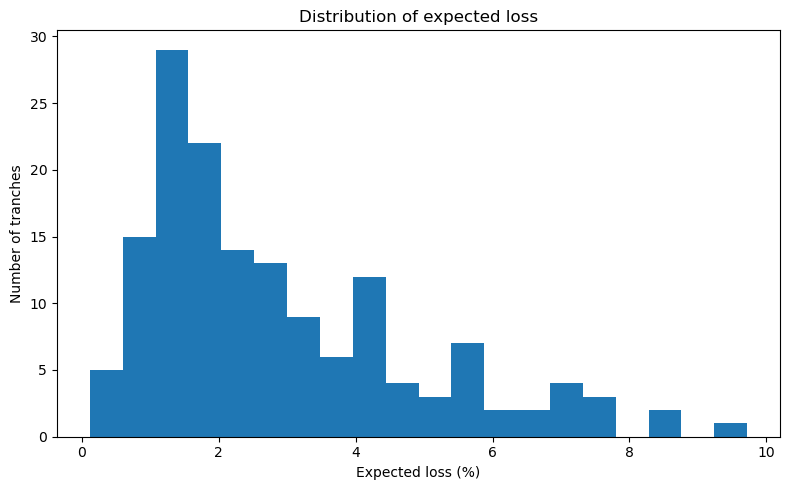

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(reg["expected_loss_pct"].dropna(), bins=20)
plt.xlabel("Expected loss (%)")
plt.ylabel("Number of tranches")
plt.title("Distribution of expected loss")
plt.tight_layout()
plt.show()

## Distribution of spread

The same kind of histogram for the dependent variable, spread. Shows the overall range and skew of spreads we are trying to explain.

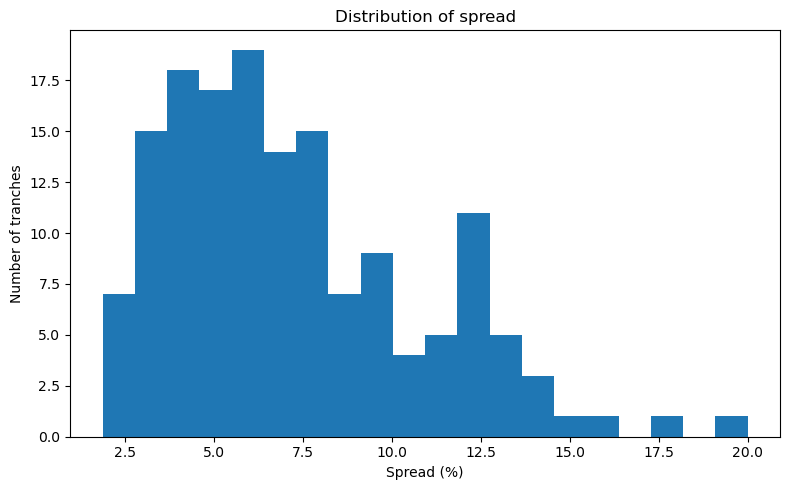

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(reg["spread_pct"].dropna(), bins=20)
plt.xlabel("Spread (%)")
plt.ylabel("Number of tranches")
plt.title("Distribution of spread")
plt.tight_layout()
plt.show()

## Spread versus expected loss

This is the central relationship in the whole paper. We scatter spread against expected loss and overlay a simple fitted line just for visual reference. The clear upward slope is the first piece of evidence that higher expected loss goes with higher spread, which the regressions then quantify and confirm. The printed slope is only an eyeball check, not the model estimate.

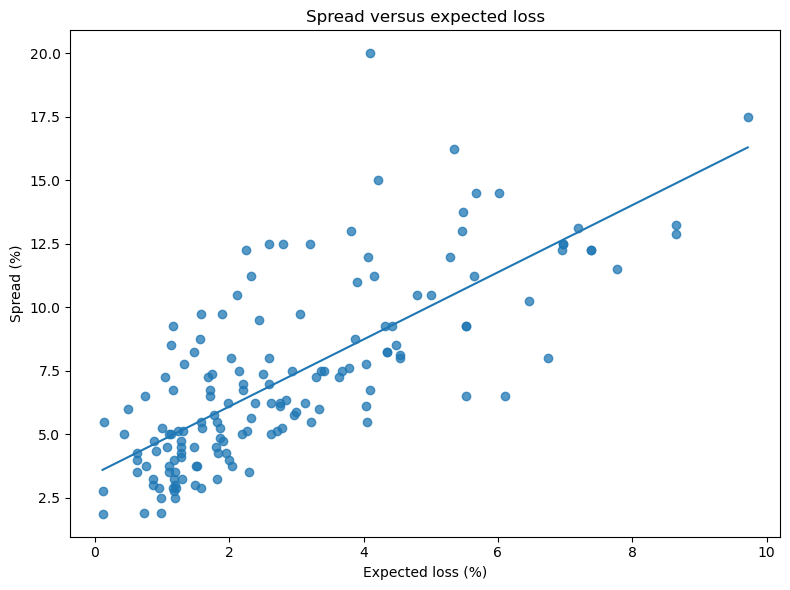

Visual fitted line: spread = 3.448 + 1.322 * expected_loss


In [15]:
x = reg["expected_loss_pct"]
y = reg["spread_pct"]

# Simple fitted line for visual interpretation.
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.75)
plt.plot(x_line, y_line)
plt.xlabel("Expected loss (%)")
plt.ylabel("Spread (%)")
plt.title("Spread versus expected loss")
plt.tight_layout()
plt.show()

print(f"Visual fitted line: spread = {intercept:.3f} + {slope:.3f} * expected_loss")

## Correlation matrix

A quick numeric look at how the continuous variables move together. It's a complementary check to the scatter plot and a basic guard against obvious collinearity issues before we put everything into the same regression.

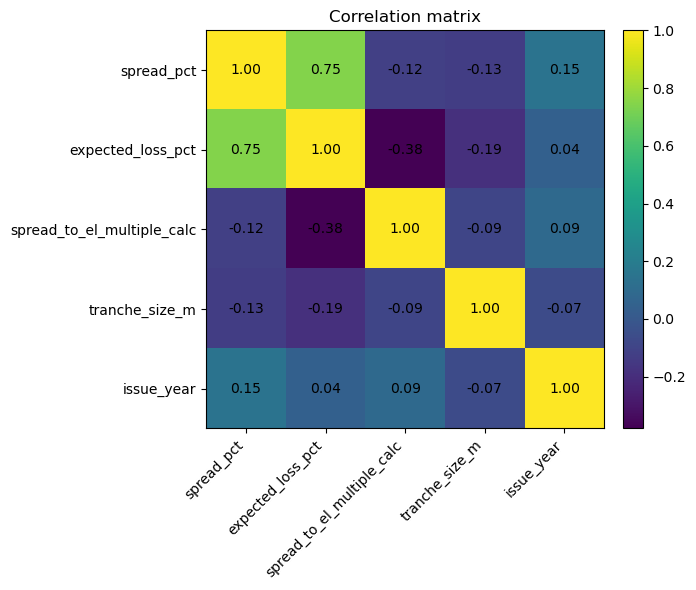

,spread_pct,expected_loss_pct,spread_to_el_multiple_calc,tranche_size_m,issue_year
spread_pct,1.000,0.745,-0.117,-0.127,0.147
expected_loss_pct,0.745,1.000,-0.379,-0.187,0.044
spread_to_el_multiple_calc,-0.117,-0.379,1.000,-0.091,0.091
tranche_size_m,-0.127,-0.187,-0.091,1.000,-0.066
issue_year,0.147,0.044,0.091,-0.066,1.000


In [16]:
corr_vars = ["spread_pct", "expected_loss_pct", "spread_to_el_multiple_calc", "tranche_size_m", "issue_year"]
corr = reg[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr

## Average spread and expected loss by year

Plots average spread and average expected loss for each issue year side by side. This is the key motivation for adding issuance-year controls: average spread moves around noticeably across years while average expected loss stays comparatively flat, which hints that something beyond modelled loss, i.e. market conditions at the time of issuance, is influencing spreads. This is the figure behind the time-variation argument in the paper.

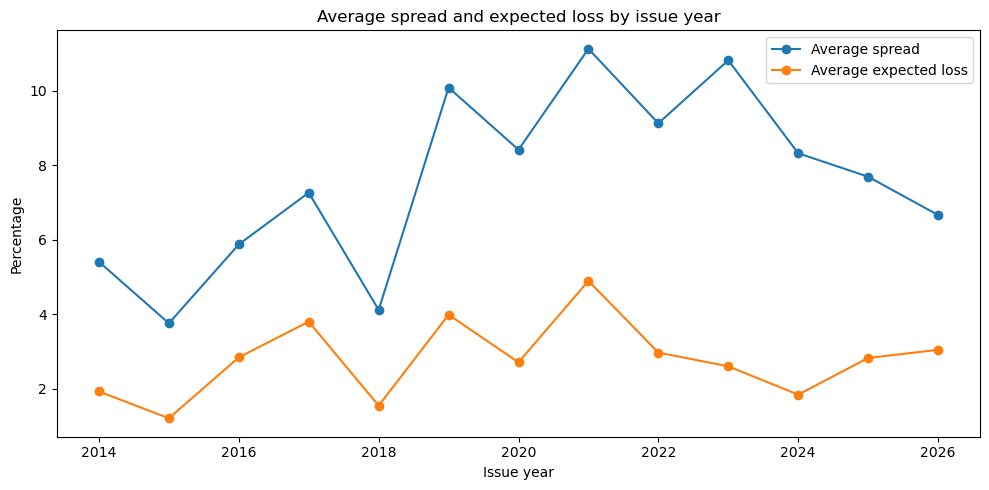

,issue_year,n,avg_spread_pct,avg_expected_loss_pct,median_spread_pct
0,2014,7,5.407,1.926,5.000
1,2015,4,3.756,1.208,3.500
2,2016,9,5.875,2.842,5.000
3,2017,19,7.263,3.801,6.500
4,2018,9,4.117,1.544,2.875
5,2019,3,10.083,3.987,11.250
6,2020,6,8.417,2.709,8.250
7,2021,2,11.125,4.895,11.125
8,2022,4,9.125,2.970,8.625
9,2023,9,10.817,2.602,12.250


In [17]:
year_summary = (
    reg.groupby("issue_year", observed=True)
       .agg(
           n=("spread_pct", "size"),
           avg_spread_pct=("spread_pct", "mean"),
           avg_expected_loss_pct=("expected_loss_pct", "mean"),
           median_spread_pct=("spread_pct", "median")
       )
       .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(year_summary["issue_year"], year_summary["avg_spread_pct"], marker="o", label="Average spread")
plt.plot(year_summary["issue_year"], year_summary["avg_expected_loss_pct"], marker="o", label="Average expected loss")
plt.xlabel("Issue year")
plt.ylabel("Percentage")
plt.title("Average spread and expected loss by issue year")
plt.legend()
plt.tight_layout()
plt.show()

year_summary

## Spread by trigger type

A first descriptive look at whether spreads differ by trigger mechanism, via a box plot plus a summary table of average spread and expected loss per trigger. Read this alongside the next regressions: industry-loss tranches look more expensive here, but they also carry higher expected loss, which is why the trigger effect largely disappears once expected loss is controlled for.

<Figure size 1000x500 with 0 Axes>

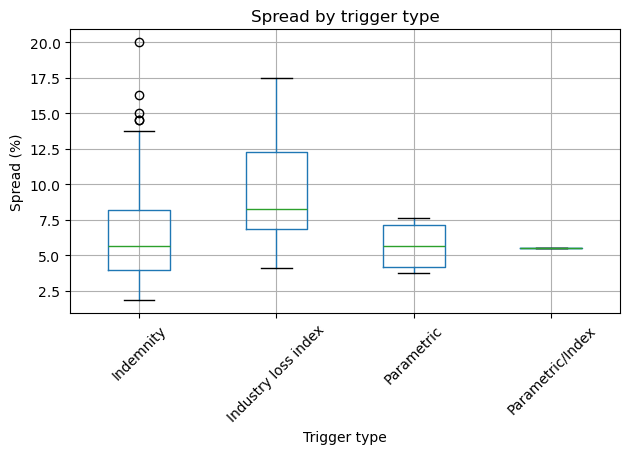

,n,avg_spread_pct,median_spread_pct,avg_expected_loss_pct
trigger_type,,,,
Industry loss index,38,9.089,8.250,4.441
Indemnity,110,6.621,5.688,2.307
Parametric,4,5.681,5.675,2.197
Parametric/Index,1,5.500,5.500,3.220


In [18]:
trigger_summary = (
    reg.groupby("trigger_type", observed=True)
       .agg(
           n=("spread_pct", "size"),
           avg_spread_pct=("spread_pct", "mean"),
           median_spread_pct=("spread_pct", "median"),
           avg_expected_loss_pct=("expected_loss_pct", "mean")
       )
       .sort_values("avg_spread_pct", ascending=False)
)

plt.figure(figsize=(10, 5))
reg.boxplot(column="spread_pct", by="trigger_type", rot=45)
plt.suptitle("")
plt.title("Spread by trigger type")
plt.xlabel("Trigger type")
plt.ylabel("Spread (%)")
plt.tight_layout()
plt.show()

trigger_summary

## Spread by broad peril category

The same descriptive check for perils. The box plot and table show that spreads do seem to differ across peril categories. The regressions then test whether these differences hold up after accounting for expected loss, trigger, and year, which for most perils they do.

<Figure size 1000x500 with 0 Axes>

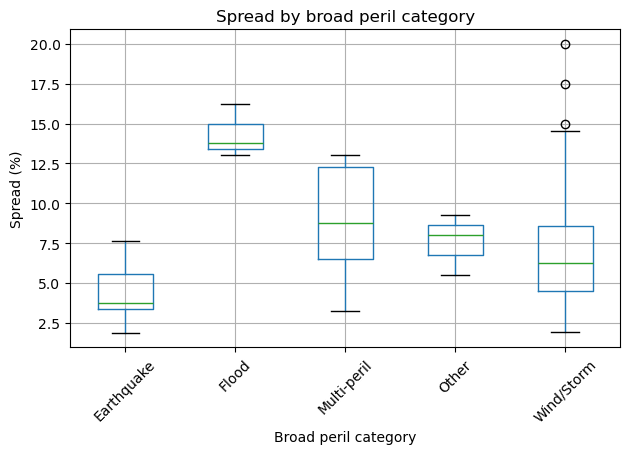

,n,avg_spread_pct,median_spread_pct,avg_expected_loss_pct
broad_peril,,,,
Flood,3,14.333,13.750,5.433
Multi-peril,28,8.705,8.750,3.717
Other,3,7.583,8.000,2.133
Wind/Storm,100,7.084,6.250,2.706
Earthquake,19,4.420,3.750,1.954


In [19]:
peril_summary = (
    reg.groupby("broad_peril", observed=True)
       .agg(
           n=("spread_pct", "size"),
           avg_spread_pct=("spread_pct", "mean"),
           median_spread_pct=("spread_pct", "median"),
           avg_expected_loss_pct=("expected_loss_pct", "mean")
       )
       .sort_values("avg_spread_pct", ascending=False)
)

plt.figure(figsize=(10, 5))
reg.boxplot(column="spread_pct", by="broad_peril", rot=45)
plt.suptitle("")
plt.title("Spread by broad peril category")
plt.xlabel("Broad peril category")
plt.ylabel("Spread (%)")
plt.tight_layout()
plt.show()

peril_summary

## Spread-to-expected-loss multiple

The spread-to-expected-loss ratio is used to assess the premium investors receive relative to the modelled expected loss. This ratio is relevant because spreads generally exceed expected losses, meaning that the ratio captures how large this premium is. The distribution is right-skewed, mainly because the ratio increases sharply for tranches with very low expected loss values. This should therefore be kept in mind when interpreting extreme values in the ratio.

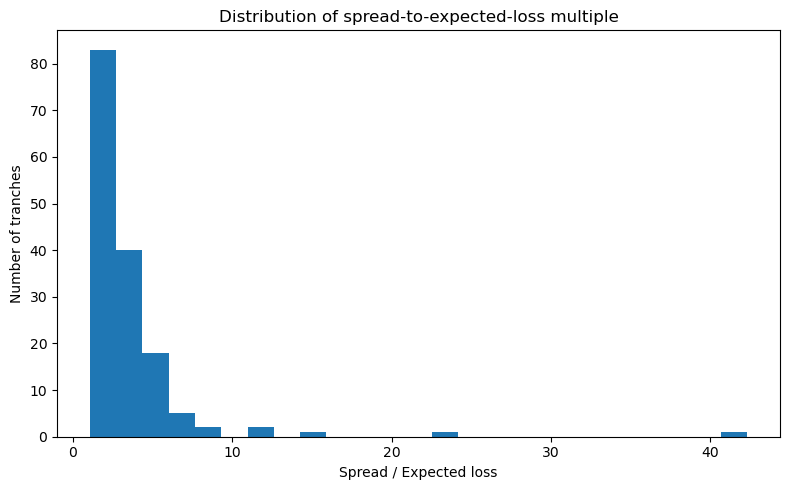

count   153.000
mean      3.623
std       4.099
min       1.066
25%       1.997
50%       2.551
75%       3.893
max      42.308
Name: spread_to_el_multiple_calc, dtype: float64

In [20]:
multiple = reg["spread_to_el_multiple_calc"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8, 5))
plt.hist(multiple, bins=25)
plt.xlabel("Spread / Expected loss")
plt.ylabel("Number of tranches")
plt.title("Distribution of spread-to-expected-loss multiple")
plt.tight_layout()
plt.show()

multiple.describe()

## Outlier check

Lists the tranches with the highest spreads, highest expected losses, and highest spread-to-expected-loss multiples, with their source URLs so we can trace them back to Artemis. These rows aren't necessarily errors, but because a small sample is sensitive to extreme points, we want to see them explicitly and be able to verify they are real deals rather than data-entry mistakes.

In [21]:
outliers = reg.assign(
    spread_rank=reg["spread_pct"].rank(ascending=False),
    el_rank=reg["expected_loss_pct"].rank(ascending=False),
    multiple_rank=reg["spread_to_el_multiple_calc"].rank(ascending=False)
)

cols = [
    "deal_name", "tranche_class", "issue_year", "expected_loss_pct", "spread_pct",
    "spread_to_el_multiple_calc", "trigger_type", "broad_peril", "source_url"
]

print("Highest spreads:")
display(outliers.sort_values("spread_pct", ascending=False)[cols].head(10))

print("Highest expected losses:")
display(outliers.sort_values("expected_loss_pct", ascending=False)[cols].head(10))

print("Highest spread-to-expected-loss multiples:")
display(outliers.sort_values("spread_to_el_multiple_calc", ascending=False)[cols].head(10))

Highest spreads:


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,spread_to_el_multiple_calc,trigger_type,broad_peril,source_url
75,Bonanza Re Ltd. (Series 2024-1),Class A,2024,4.090,20.000,4.890,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/bonanza-...
28,Galileo Re Ltd. (Series 2017-1),Class B,2017,9.720,17.500,1.800,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galileo-...
65,FloodSmart Re Ltd. (Series 2023-1),Class A,2023,5.350,16.250,3.037,Indemnity,Flood,https://www.artemis.bm/deal-directory/floodsma...
120,Armor Re II Ltd. (Series 2026-1),Class B,2026,4.220,15.000,3.555,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/armor-re...
53,FloodSmart Re Ltd. (Series 2020-1),Class B,2020,5.680,14.500,2.553,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/floodsma...
50,FloodSmart Re Ltd. (Series 2019-1),Class B,2019,6.010,14.500,2.413,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/floodsma...
61,FloodSmart Re Ltd. (Series 2022-1),Class B,2022,5.480,13.750,2.509,Indemnity,Flood,https://www.artemis.bm/deal-directory/floodsma...
22,Galilei Re Ltd. (Series 2017-1),Class A-2,2017,8.650,13.250,1.532,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galilei-...
102,Montoya Re Ltd. (Series 2025-2),Class B,2025,7.190,13.125,1.825,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/montoya-...
73,Titania Re Ltd. (Series 2023-1),Class B,2023,3.820,13.000,3.403,Indemnity,Multi-peril,https://www.artemis.bm/deal-directory/titania-...


Highest expected losses:


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,spread_to_el_multiple_calc,trigger_type,broad_peril,source_url
28,Galileo Re Ltd. (Series 2017-1),Class B,2017,9.720,17.500,1.800,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galileo-...
15,Galilei Re Ltd. (Series 2016-1),Class A-1,2016,8.650,12.875,1.488,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galilei-...
22,Galilei Re Ltd. (Series 2017-1),Class A-2,2017,8.650,13.250,1.532,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/galilei-...
98,Meadows Ltd. (Series 2025-1),Class B,2025,7.770,11.500,1.480,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/meadows-...
136,Kilimanjaro III Re Ltd. (Series 2026-2),Class D,2026,7.380,12.250,1.660,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
132,Kilimanjaro III Re Ltd. (Series 2026-1),Class D,2026,7.380,12.250,1.660,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
102,Montoya Re Ltd. (Series 2025-2),Class B,2025,7.190,13.125,1.825,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/montoya-...
130,Kilimanjaro III Re Ltd. (Series 2026-1),Class B,2026,6.970,12.500,1.793,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
134,Kilimanjaro III Re Ltd. (Series 2026-2),Class B,2026,6.970,12.500,1.793,Industry loss index,Multi-peril,https://www.artemis.bm/deal-directory/kilimanj...
97,Meadows Ltd. (Series 2025-1),Class A,2025,6.960,12.250,1.760,Industry loss index,Wind/Storm,https://www.artemis.bm/deal-directory/meadows-...


Highest spread-to-expected-loss multiples:


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,spread_to_el_multiple_calc,trigger_type,broad_peril,source_url
125,Buttonwood Re Ltd. (Series 2026-1),Class D,2026,0.130,5.500,42.308,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/buttonwo...
56,Stratosphere Re Ltd. (Series 2020-1),Class A,2020,0.115,2.750,23.913,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/stratosp...
45,Kizuna Re II Ltd. (Series 2018-1),Class A,2018,0.120,1.875,15.625,Indemnity,Earthquake,https://www.artemis.bm/deal-directory/kizuna-r...
156,Winston Re Ltd. (Series 2026-1),Class C,2026,0.490,6.000,12.245,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/winston-...
119,Armor Re II Ltd. (Series 2026-1),Class A,2026,0.440,5.000,11.364,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/armor-re...
71,Residential Reinsurance 2023 Limited (Series 2...,Class 14,2023,0.750,6.500,8.667,Indemnity,Multi-peril,https://www.artemis.bm/deal-directory/resident...
63,Yosemite Re Ltd. (Series 2022-1),Class A,2022,1.160,9.250,7.974,Indemnity,Other,https://www.artemis.bm/deal-directory/yosemite...
74,Bayou Re Ltd. (Series 2024-1),Class A,2024,1.140,8.500,7.456,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/bayou-re...
105,Purple Re Ltd. (Series 2025-1),Class A,2025,1.050,7.250,6.905,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/purple-r...
112,Sanders Re II Ltd. (Series 2025-1),Class A-2,2025,0.622,4.250,6.832,Indemnity,Wind/Storm,https://www.artemis.bm/deal-directory/sanders-...


# Regression analysis

This is the core of the paper. We estimate the spread as a function of expected loss and then progressively add trigger type, peril type, and issuance-year fixed effects. Building the model up in steps lets us see how much explanatory power each group of variables adds on top of the previous one. All regressions use heteroskedasticity-robust (HC3) standard errors, since the spread of residuals is unlikely to be constant across low- and high-risk tranches.

## Model 1: expected loss only

The simplest specification: spread explained by expected loss alone. This is the baseline and the most direct test of our main expectation, that higher expected loss means higher spread. The coefficient here (around 1.3) and its R-squared become the reference point that the later, richer models are compared against.

In [22]:
model1 = smf.ols("spread_pct ~ expected_loss_pct", data=reg).fit(cov_type="HC3")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     223.0
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           1.52e-31
Time:                        17:10:52   Log-Likelihood:                -348.22
No. Observations:                 153   AIC:                             700.4
Df Residuals:                     151   BIC:                             706.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.4485      0.27

## Adding trigger and peril controls

A version of the model that adds trigger type and peril category on top of expected loss. This checks whether contract design and the underlying peril explain spread differences that expected loss alone misses. (Note: the clean stepwise M1–M4 sequence used for the paper's table is assembled a couple of cells below; this cell is an intermediate exploration.)

In [23]:
model2 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril)",
    data=reg
).fit(cov_type="HC3")

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     50.65
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           3.82e-38
Time:                        17:10:52   Log-Likelihood:                -335.09
No. Observations:                 153   AIC:                             688.2
Df Residuals:                     144   BIC:                             715.5
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

## Full models with issuance-year controls and the paper's regression table

The cells in this block estimate the regressions reported in the paper. First a full specification adds issuance-year fixed effects on top of expected loss, trigger, and peril; this is where market conditions at the time of issuance get absorbed, and the jump in explanatory power when these year effects are added is one of the paper's main findings.

The clean, consistent set of four nested models used for the paper's table is then estimated together:

- **M1** — expected loss only
- **M2** — plus trigger type
- **M3** — plus peril type
- **M4** — plus issuance-year fixed effects

Defining them in one place keeps the table internally consistent and easy to reproduce, and the following cell prints the full output for all four.

In [24]:
model3 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril) + C(issue_year)",
    data=reg
).fit(cov_type="HC3")

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     42.95
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           5.87e-48
Time:                        17:10:52   Log-Likelihood:                -299.77
No. Observations:                 153   AIC:                             641.5
Df Residuals:                     132   BIC:                             705.2
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [25]:
model1 = smf.ols(
    "spread_pct ~ expected_loss_pct",
    data=reg
).fit(cov_type="HC3")

model2 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type)",
    data=reg
).fit(cov_type="HC3")

model3 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril)",
    data=reg
).fit(cov_type="HC3")

model4 = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril) + C(issue_year)",
    data=reg
).fit(cov_type="HC3")

In [26]:
# Print full regression outputs
print(model1.summary())
print(model2.summary())
print(model3.summary())
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:             spread_pct   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     223.0
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           1.52e-31
Time:                        17:10:52   Log-Likelihood:                -348.22
No. Observations:                 153   AIC:                             700.4
Df Residuals:                     151   BIC:                             706.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.4485      0.27

# Nonlinear (machine-learning) models

The OLS models assume the relationships are linear and additive. Because earlier research suggests catastrophe bond pricing can be nonlinear, we also fit three tree-based models, Random Forest, XGBoost, and CatBoost, which can capture nonlinearities and interactions on their own. These act as a robustness check on the OLS story: if the simple linear model is missing something important, the flexible models should predict noticeably better. We tune each model with Optuna and compare them to the linear benchmark using cross-validation, then interpret them with SHAP.

In [27]:
from sklearn.linear_model import LinearRegression

# NOTE: mlr_model is defined after the preprocessor is built (see below).


In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
def calculate_rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "model": model_name,
        "train_RMSE": calculate_rmse(y_train, y_train_pred),
        "test_RMSE": calculate_rmse(y_test, y_test_pred),
        "train_MAE": mean_absolute_error(y_train, y_train_pred),
        "test_MAE": mean_absolute_error(y_test, y_test_pred),
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred)
    }

In [30]:
base_data = reg.copy()

features = [
    "expected_loss_pct",
    "trigger_type",
    "broad_peril",
    "issue_year"
]

target = "spread_pct"

model_data = base_data[features + [target]].dropna().copy()

X = model_data[features]
y = model_data[target]

numeric_features = ["expected_loss_pct", "issue_year"]
categorical_features = ["trigger_type", "broad_peril"]

print("Sample size:", len(model_data))
display(model_data.head())

Sample size: 153


,expected_loss_pct,trigger_type,broad_peril,issue_year,spread_pct
0,2.840,Indemnity,Wind/Storm,2014,6.350
1,1.280,Indemnity,Wind/Storm,2014,4.250
2,2.200,Indemnity,Multi-peril,2014,6.750
3,1.140,Indemnity,Multi-peril,2014,5.000
4,2.200,Indemnity,Multi-peril,2014,7.000


**A note on the train/test split below**

The split that follows is used **only** to provide the training data that Optuna needs while searching for good hyperparameters. It is *not* the basis for the final model comparison. The headline comparison reported in the paper uses 5-fold cross-validation on the full sample (further down), because with only 153 observations a single random split is unstable and can swing a lot depending on which tranches happen to land in the test set. The held-out split is kept around only as a secondary robustness check.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 114
Test observations: 39


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", make_onehot_encoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [33]:
# mlr_model defined here, after preprocessor is available
mlr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

mlr_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [34]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
n_trials = 40

In [35]:
def objective_random_forest(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    return np.sqrt(-scores).mean()

In [36]:
def objective_xgboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    return np.sqrt(-scores).mean()

In [37]:
def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "loss_function": "RMSE",
        "verbose": False,
        "random_seed": 42
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostRegressor(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    return np.sqrt(-scores).mean()

In [38]:
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_random_forest, n_trials=n_trials)

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgboost, n_trials=n_trials)

study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_catboost, n_trials=n_trials)

print("Best RF CV RMSE:", study_rf.best_value)
print("Best RF params:", study_rf.best_params)

print("\nBest XGBoost CV RMSE:", study_xgb.best_value)
print("Best XGBoost params:", study_xgb.best_params)

print("\nBest CatBoost CV RMSE:", study_cat.best_value)
print("Best CatBoost params:", study_cat.best_params)

Best RF CV RMSE: 2.1814995768172856
Best RF params: {'n_estimators': 574, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}

Best XGBoost CV RMSE: 2.1380213688796084
Best XGBoost params: {'n_estimators': 607, 'max_depth': 3, 'learning_rate': 0.030763813078718904, 'subsample': 0.9605878905224656, 'colsample_bytree': 0.6316877968147738, 'min_child_weight': 5.50432214182134, 'reg_alpha': 0.4083202548035819, 'reg_lambda': 1.3803175142469135}

Best CatBoost CV RMSE: 2.1007132100297645
Best CatBoost params: {'iterations': 609, 'depth': 6, 'learning_rate': 0.039374117587959556, 'l2_leaf_reg': 6.327871253414646, 'random_strength': 4.438368553438145, 'bagging_temperature': 4.446191418545896}


In [39]:
best_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        **study_rf.best_params,
        random_state=42,
        n_jobs=-1
    ))
])

best_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study_xgb.best_params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

best_cat = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        **study_cat.best_params,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    ))
])

best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
best_cat.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Cross-validated model comparison 

The model comparison is based on 5-fold cross-validation and reports RMSE, MAE, and R^2 for all four models. This includes the linear benchmark and the three tuned tree-based models, using the best hyperparameters identified by Optuna. Applying the same folds to every model makes the comparison more reliable than relying on a single train-test split, especially given the limited sample size. The standard deviation across folds is also reported, as this shows how stable the model performance is across different parts of the sample.

One limitation is that the hyperparameters of the tree-based models were tuned on the training partition before the models were evaluated across folds of the full dataset. This means that their cross-validated performance may be slightly optimistic. A fully unbiased approach would require nested cross-validation, where tuning is repeated within each outer fold. However, given the computational burden and the scope of this study, this is treated as a limitation rather than implemented.

In [40]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import LinearRegression

# Rebuild pipelines with tuned params (do NOT re-tune; just use Optuna best params)
cv_mlr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

cv_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        **study_rf.best_params,
        random_state=42, n_jobs=-1
    ))
])

cv_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study_xgb.best_params,
        objective="reg:squarederror",
        random_state=42, n_jobs=-1
    ))
])

cv_cat = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        **study_cat.best_params,
        loss_function="RMSE",
        verbose=False, random_seed=42
    ))
])

# 5-fold CV on the full dataset
cv_full = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"]

model_cv_specs = {
    "Multiple linear regression": cv_mlr,
    "Random Forest":              cv_rf,
    "XGBoost":                    cv_xgb,
    "CatBoost":                   cv_cat,
}

cv_rows = []
for name, pipe in model_cv_specs.items():
    res = cross_validate(pipe, X, y, cv=cv_full, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model":       name,
        "CV RMSE (mean)": (-res["test_neg_root_mean_squared_error"]).mean(),
        "CV RMSE (std)":  (-res["test_neg_root_mean_squared_error"]).std(),
        "CV MAE (mean)":  (-res["test_neg_mean_absolute_error"]).mean(),
        "CV MAE (std)":   (-res["test_neg_mean_absolute_error"]).std(),
        "CV R² (mean)":   res["test_r2"].mean(),
        "CV R² (std)":    res["test_r2"].std(),
    })

cv_comparison = pd.DataFrame(cv_rows).sort_values("CV RMSE (mean)").reset_index(drop=True)
print("PRIMARY TABLE III — 5-fold cross-validated model comparison (full sample)")
display(cv_comparison)


PRIMARY TABLE III — 5-fold cross-validated model comparison (full sample)


,Model,CV RMSE (mean),CV RMSE (std),CV MAE (mean),CV MAE (std),CV R² (mean),CV R² (std)
0,CatBoost,1.831,0.419,1.333,0.252,0.705,0.091
1,XGBoost,1.926,0.457,1.418,0.306,0.673,0.114
2,Random Forest,1.929,0.385,1.438,0.228,0.678,0.066
3,Multiple linear regression,2.330,0.323,1.717,0.174,0.511,0.139


## Single-split robustness check (secondary)

This evaluates each tuned model once, on the 25% held-out test set, as a secondary check. We report it only to show the conclusions don't hinge on the cross-validation setup; it is not the primary result. Because a single split depends heavily on which observations end up in the test set, these numbers should not be over-interpreted, which is exactly why the cross-validated table above is the one we lead with.

In [41]:
test_comparison = pd.DataFrame([
    evaluate_model("Multiple linear regression", mlr_model, X_train, X_test, y_train, y_test),
    evaluate_model("Random Forest", best_rf, X_train, X_test, y_train, y_test),
    evaluate_model("XGBoost", best_xgb, X_train, X_test, y_train, y_test),
    evaluate_model("CatBoost", best_cat, X_train, X_test, y_train, y_test)
])

test_comparison = test_comparison.sort_values("test_RMSE").reset_index(drop=True)

display(test_comparison)

,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2
0,Random Forest,1.247,1.621,0.866,1.284,0.880,0.763
1,CatBoost,0.935,1.705,0.621,1.278,0.932,0.738
2,XGBoost,1.142,1.777,0.763,1.334,0.899,0.715
3,Multiple linear regression,2.139,2.331,1.499,1.739,0.646,0.510


In [42]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
def get_transformed_data(fitted_pipeline, X):
    """
    Applies the fitted preprocessing step and returns a dataframe
    with readable feature names.
    """
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    feature_names = fitted_preprocessor.get_feature_names_out()
    X_transformed = fitted_preprocessor.transform(X)

    return pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )


def calculate_tree_shap(fitted_pipeline, X):
    """
    Calculates SHAP values for a fitted tree-based pipeline.
    """
    X_transformed = get_transformed_data(fitted_pipeline, X)
    fitted_model = fitted_pipeline.named_steps["model"]

    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_transformed)

    shap_importance = pd.DataFrame({
        "feature": X_transformed.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    return shap_importance, shap_values, X_transformed

In [44]:
tree_models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "CatBoost": best_cat
}

shap_outputs = {}

for model_name, model in tree_models.items():
    importance, shap_values, X_test_transformed = calculate_tree_shap(model, X_test)

    shap_outputs[model_name] = {
        "importance": importance,
        "shap_values": shap_values,
        "X_test_transformed": X_test_transformed
    }

    print(model_name)
    display(importance.head(15))
    

Random Forest


,feature,mean_abs_shap
9,num__expected_loss_pct,2.118
10,num__issue_year,0.632
4,cat__broad_peril_Earthquake,0.289
1,cat__trigger_type_Industry loss index,0.216
0,cat__trigger_type_Indemnity,0.103
6,cat__broad_peril_Multi-peril,0.097
5,cat__broad_peril_Flood,0.084
8,cat__broad_peril_Wind/Storm,0.076
7,cat__broad_peril_Other,0.017
3,cat__trigger_type_Parametric/Index,0.008


XGBoost


,feature,mean_abs_shap
9,num__expected_loss_pct,2.748
10,num__issue_year,1.064
4,cat__broad_peril_Earthquake,0.275
1,cat__trigger_type_Industry loss index,0.178
0,cat__trigger_type_Indemnity,0.145
8,cat__broad_peril_Wind/Storm,0.115
6,cat__broad_peril_Multi-peril,0.111
2,cat__trigger_type_Parametric,0.000
3,cat__trigger_type_Parametric/Index,0.000
5,cat__broad_peril_Flood,0.000


CatBoost


,feature,mean_abs_shap
9,num__expected_loss_pct,2.514
10,num__issue_year,0.960
4,cat__broad_peril_Earthquake,0.225
1,cat__trigger_type_Industry loss index,0.122
0,cat__trigger_type_Indemnity,0.099
6,cat__broad_peril_Multi-peril,0.084
8,cat__broad_peril_Wind/Storm,0.083
5,cat__broad_peril_Flood,0.021
7,cat__broad_peril_Other,0.019
3,cat__trigger_type_Parametric/Index,0.014


Random Forest


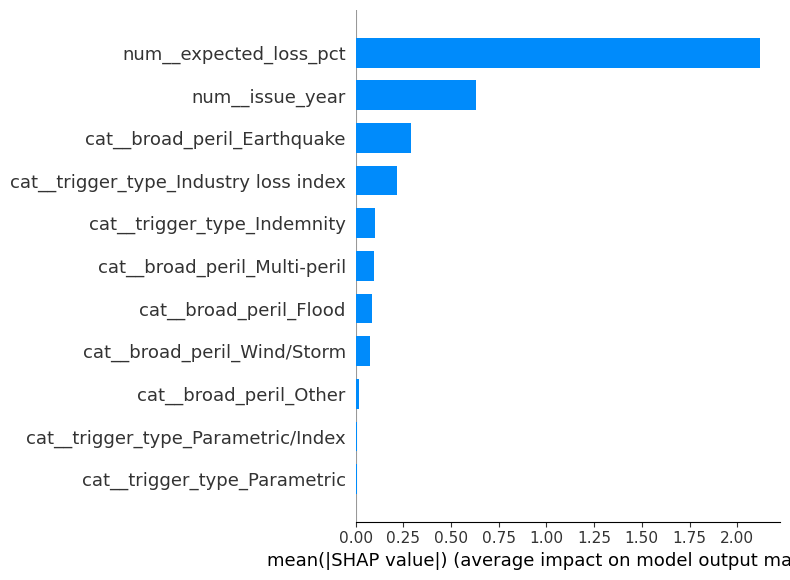

XGBoost


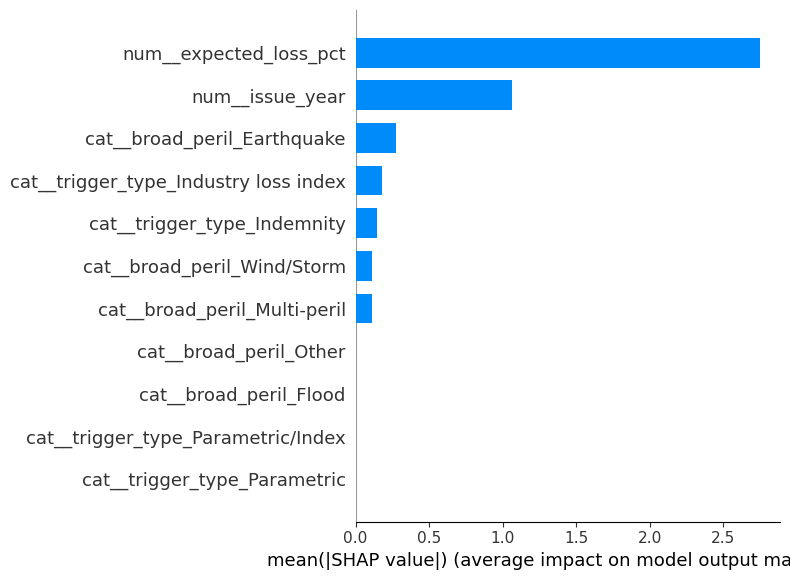

CatBoost


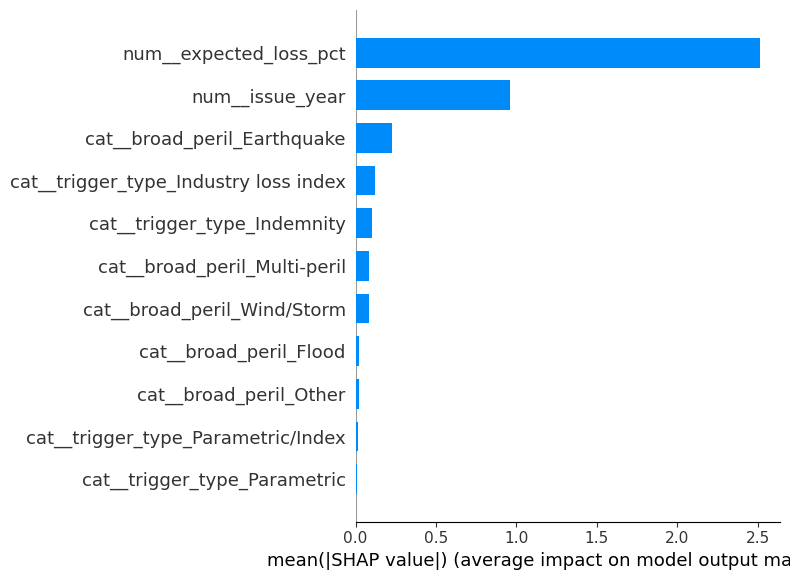

In [45]:
for model_name in tree_models.keys():
    print(model_name)

    shap.summary_plot(
        shap_outputs[model_name]["shap_values"],
        shap_outputs[model_name]["X_test_transformed"],
        plot_type="bar",
        max_display=15
    )

Random Forest


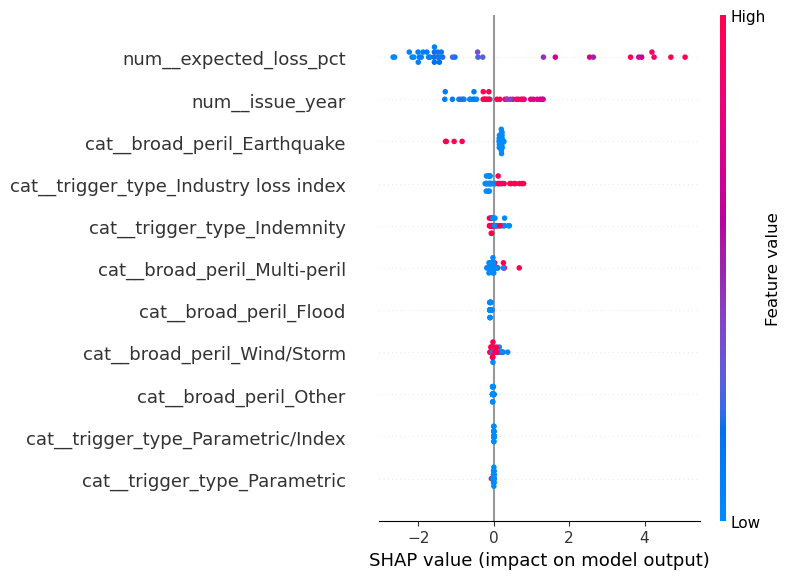

XGBoost


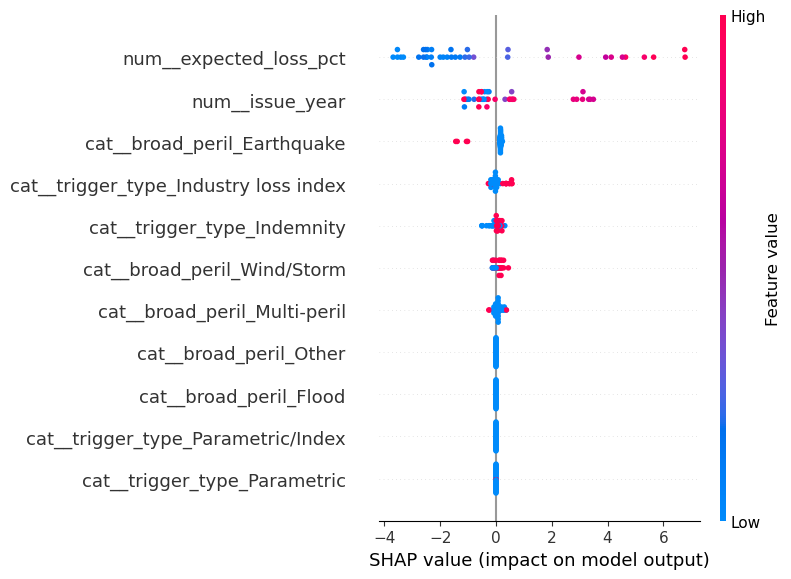

CatBoost


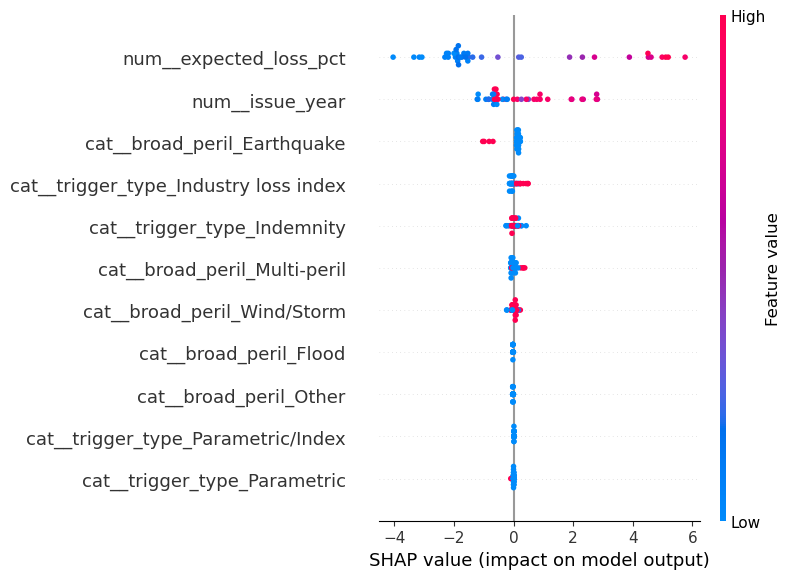

In [46]:
for model_name in tree_models.keys():
    print(model_name)

    shap.summary_plot(
        shap_outputs[model_name]["shap_values"],
        shap_outputs[model_name]["X_test_transformed"],
        max_display=15
    )

In [47]:
def group_feature_name(feature):
    if "expected_loss_pct" in feature:
        return "expected_loss_pct"
    elif "issue_year" in feature:
        return "issue_year"
    elif "trigger_type" in feature:
        return "trigger_type"
    elif "broad_peril" in feature:
        return "broad_peril"
    else:
        return feature


grouped_shap_list = []

for model_name in tree_models.keys():
    temp = shap_outputs[model_name]["importance"].copy()
    temp["feature_group"] = temp["feature"].apply(group_feature_name)

    grouped = (
        temp
        .groupby("feature_group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )

    grouped["model"] = model_name
    grouped_shap_list.append(grouped)

grouped_shap_importance = pd.concat(grouped_shap_list, ignore_index=True)

display(grouped_shap_importance)

,feature_group,mean_abs_shap,model
0,expected_loss_pct,2.118,Random Forest
1,issue_year,0.632,Random Forest
2,broad_peril,0.563,Random Forest
3,trigger_type,0.334,Random Forest
4,expected_loss_pct,2.748,XGBoost
5,issue_year,1.064,XGBoost
6,broad_peril,0.501,XGBoost
7,trigger_type,0.323,XGBoost
8,expected_loss_pct,2.514,CatBoost
9,issue_year,0.960,CatBoost


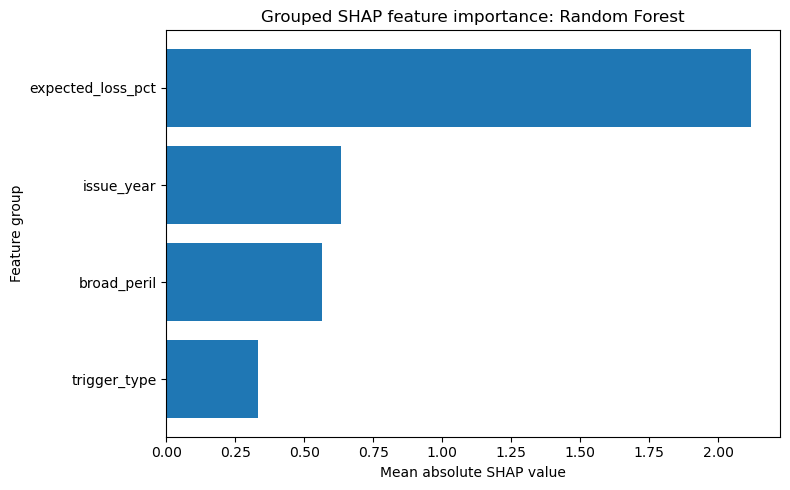

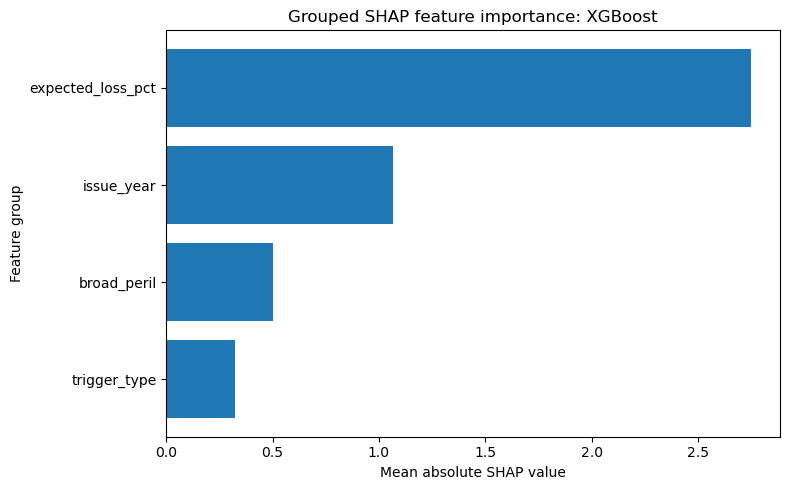

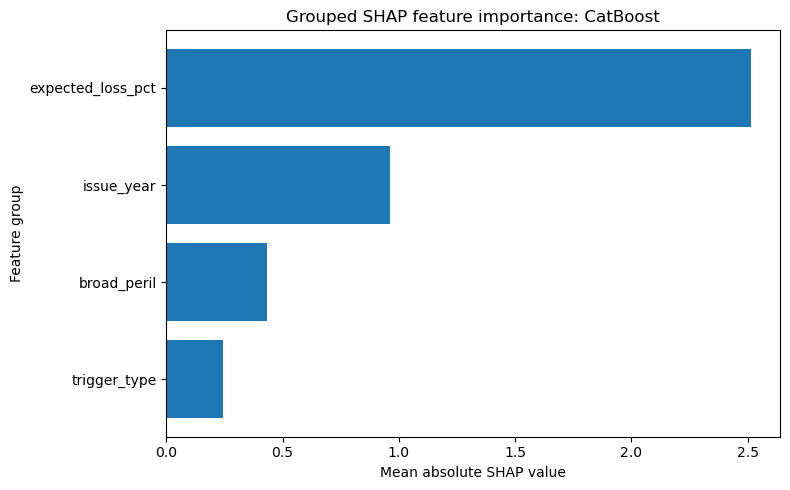

In [48]:
for model_name in ["Random Forest", "XGBoost", "CatBoost"]:
    plot_data = (
        grouped_shap_importance[
            grouped_shap_importance["model"] == model_name
        ]
        .sort_values("mean_abs_shap", ascending=True)
    )

    plt.figure(figsize=(8, 5))
    plt.barh(
        plot_data["feature_group"],
        plot_data["mean_abs_shap"]
    )
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Feature group")
    plt.title(f"Grouped SHAP feature importance: {model_name}")
    plt.tight_layout()
    plt.show()

## OLS model comparison table

Pulls the four OLS specifications into one compact table comparing sample size, R-squared, adjusted R-squared, and information criteria. Adjusted R-squared is the one we focus on in the paper, since it penalises adding extra variables and so makes the step-by-step models comparable. This is the source of the explanatory-power numbers quoted in the Results section.

In [49]:
model_comparison = pd.DataFrame({
    "Model": ["M1: EL only", "M2: + trigger", "M3: + peril", "M4: + year FE"],
    "Dependent variable": ["spread_pct", "spread_pct", "spread_pct", "spread_pct"],
    "N": [int(m.nobs) for m in [model1, model2, model3, model4]],
    "R_squared": [m.rsquared for m in [model1, model2, model3, model4]],
    "Adj_R_squared": [m.rsquared_adj for m in [model1, model2, model3, model4]],
    "AIC": [m.aic for m in [model1, model2, model3, model4]],
    "BIC": [m.bic for m in [model1, model2, model3, model4]],
})

model_comparison


,Model,Dependent variable,N,R_squared,Adj_R_squared,AIC,BIC
0,M1: EL only,spread_pct,153,0.555,0.552,700.447,706.508
1,M2: + trigger,spread_pct,153,0.561,0.549,704.413,719.565
2,M3: + peril,spread_pct,153,0.625,0.604,688.187,715.461
3,M4: + year FE,spread_pct,153,0.764,0.728,641.533,705.172


## Extract key coefficients for interpretation

Reformats the regression output into a tidy table of coefficients, standard errors, p-values, and confidence intervals across the four models, then focuses on the expected-loss coefficient. This makes it easy to show, in one place, that the expected-loss effect stays positive, significant, and remarkably stable (around 1.3) no matter which controls are added, which is the backbone of the paper's main conclusion.

In [50]:
def tidy_model(model, model_name):
    result = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "std_error": model.bse.values,
        "p_value": model.pvalues.values,
        "ci_low": model.conf_int()[0].values,
        "ci_high": model.conf_int()[1].values,
    })
    result.insert(0, "model", model_name)
    return result

tidy_results = pd.concat([
    tidy_model(model1, "M1"),
    tidy_model(model2, "M2"),
    tidy_model(model3, "M3"),
    tidy_model(model4, "M4")
], ignore_index=True)

# Show the most important expected-loss coefficient across models.
tidy_results[tidy_results["term"].isin(["expected_loss_pct", "log_expected_loss"])]

,model,term,coef,std_error,p_value,ci_low,ci_high
1,M1,expected_loss_pct,1.322,0.089,0.000,1.148,1.495
6,M2,expected_loss_pct,1.364,0.124,0.000,1.121,1.608
15,M3,expected_loss_pct,1.274,0.133,0.000,1.014,1.534
36,M4,expected_loss_pct,1.363,0.126,0.000,1.116,1.610


## Residual diagnostics for the main model

Standard regression checks for the full model: residuals against fitted values, the distribution of residuals, and a Q-Q plot. These help us judge whether the linear specification is reasonable and whether the robust standard errors were a sensible choice. They are diagnostic checks rather than headline results, but they support the credibility of the OLS estimates.

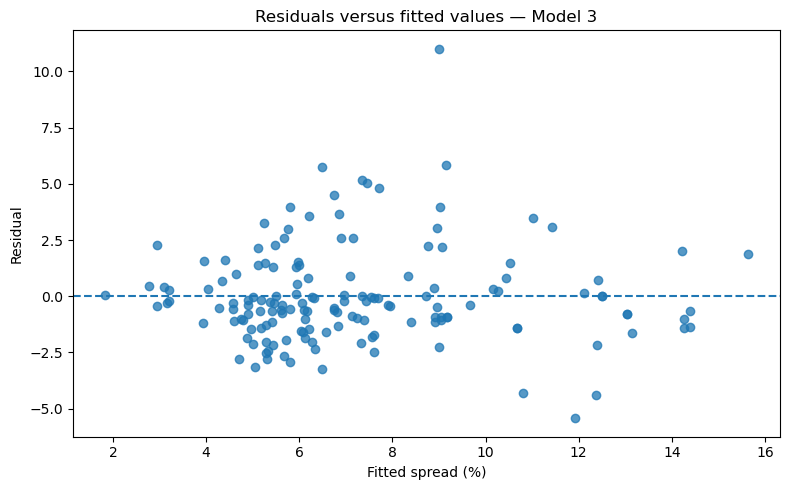

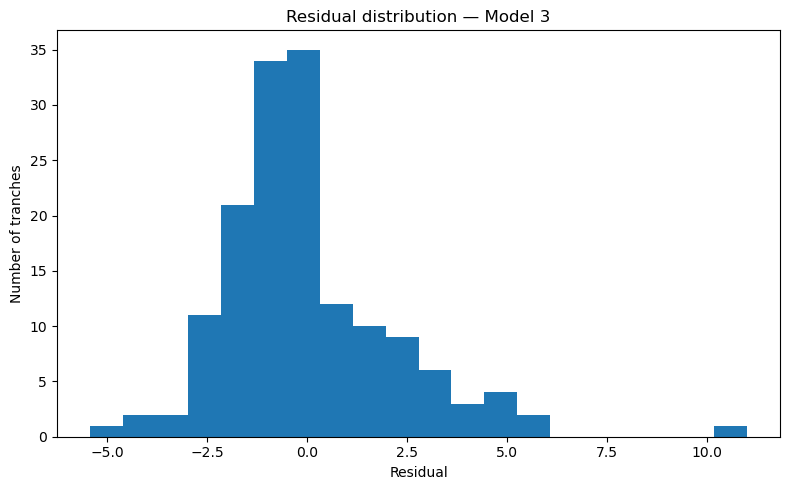

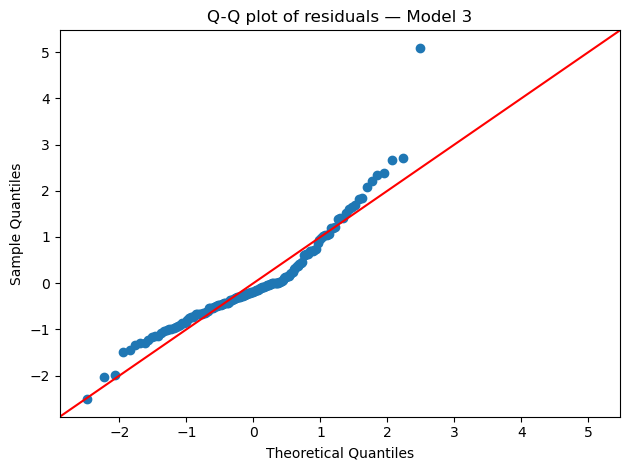

In [51]:
main_model = model3
fitted = main_model.fittedvalues
resid = main_model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted spread (%)")
plt.ylabel("Residual")
plt.title("Residuals versus fitted values — Model 3")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=20)
plt.xlabel("Residual")
plt.ylabel("Number of tranches")
plt.title("Residual distribution — Model 3")
plt.tight_layout()
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q plot of residuals — Model 3")
plt.tight_layout()
plt.show()

## Influence check

Uses Cook's distance to flag individual tranches that have an outsized effect on the regression. With a small sample, it's important to know whether any single deal is driving the results, so this lists the most influential observations (with their source URLs) so we can confirm they are legitimate rather than artefacts.

In [52]:
# Influence diagnostics require the non-robust fitted model object.
model3_nonrobust = smf.ols(
    "spread_pct ~ expected_loss_pct + C(trigger_type) + C(broad_peril) + C(issue_year)",
    data=reg
).fit()

influence = model3_nonrobust.get_influence()
reg_influence = reg.copy()
reg_influence["cooks_distance"] = influence.cooks_distance[0]

threshold = 4 / len(reg_influence)
print(f"Common Cook's distance threshold: {threshold:.4f}")

influential = reg_influence.sort_values("cooks_distance", ascending=False)[[
    "deal_name", "tranche_class", "issue_year", "expected_loss_pct", "spread_pct",
    "trigger_type", "broad_peril", "cooks_distance", "source_url"
]].head(10)

influential

Common Cook's distance threshold: 0.0261


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


,deal_name,tranche_class,issue_year,expected_loss_pct,spread_pct,trigger_type,broad_peril,cooks_distance,source_url
60,Black Kite Re Limited (Series 2022-1),Class A,2022,3.220,5.500,Parametric/Index,Other,1.621,https://www.artemis.bm/deal-directory/black-ki...
75,Bonanza Re Ltd. (Series 2024-1),Class A,2024,4.090,20.000,Indemnity,Wind/Storm,0.213,https://www.artemis.bm/deal-directory/bonanza-...
48,Alamo Re Ltd. (Series 2019-1),Class A,2019,1.800,4.500,Indemnity,Wind/Storm,0.077,https://www.artemis.bm/deal-directory/alamo-re...
76,Bonanza Re Ltd. (Series 2024-1),Class B,2024,0.760,3.750,Indemnity,Wind/Storm,0.042,https://www.artemis.bm/deal-directory/bonanza-...
64,Acorn Re Ltd. (Series 2023-1),Class A,2023,0.910,4.350,Parametric,Earthquake,0.038,https://www.artemis.bm/deal-directory/acorn-re...
77,Bonanza Re Ltd. (Series 2024-1),Class C,2024,1.820,5.500,Indemnity,Wind/Storm,0.035,https://www.artemis.bm/deal-directory/bonanza-...
63,Yosemite Re Ltd. (Series 2022-1),Class A,2022,1.160,9.250,Indemnity,Other,0.034,https://www.artemis.bm/deal-directory/yosemite...
62,Northshore Re II Ltd. (Series 2022-1),Class A,2022,2.020,8.000,Industry loss index,Other,0.034,https://www.artemis.bm/deal-directory/northsho...
50,FloodSmart Re Ltd. (Series 2019-1),Class B,2019,6.010,14.500,Indemnity,Wind/Storm,0.031,https://www.artemis.bm/deal-directory/floodsma...
143,Residential Reinsurance 2026 Limited (Series 2...,Class 14,2026,6.100,6.500,Indemnity,Multi-peril,0.026,https://www.artemis.bm/deal-directory/resident...


## Save cleaned outputs

Writes the cleaned regression sample and the summary tables (by year, trigger, and peril), the model comparison, and the coefficient table out to CSV. These are the files used to build the tables in the paper and to make the analysis reproducible from the repository.

In [53]:
output_dir = Path(".")

reg.to_csv(output_dir / "catbond_regression_sample_clean.csv", index=False)
year_summary.to_csv(output_dir / "catbond_year_summary.csv", index=False)
trigger_summary.to_csv(output_dir / "catbond_trigger_summary.csv")
peril_summary.to_csv(output_dir / "catbond_peril_summary.csv")
model_comparison.to_csv(output_dir / "catbond_model_comparison.csv", index=False)
tidy_results.to_csv(output_dir / "catbond_regression_coefficients.csv", index=False)

print("Saved cleaned datasets and summary tables as CSV files.")

Saved cleaned datasets and summary tables as CSV files.


# Interpretation notes

A short summary of how the output maps onto the paper's four expectations:

- **Expected loss:** supported if its coefficient is positive and statistically meaningful, which it clearly is across every model.
- **Trigger type:** supported only if trigger dummies matter after controlling for expected loss, which turns out to be weak and unstable here.
- **Peril type:** supported if peril categories still differ once expected loss is controlled for, which holds for most perils.
- **Issuance year:** supported if year effects add explanatory power, which they do, substantially.

Final reminder: this is an observational, hand-built sample, so the coefficients describe associations between bond characteristics and spreads, not causal effects.